In [1]:
import pandas as pd
import numpy as np
from utils import Utils
import matplotlib.pyplot as plt

In [2]:
# Step 1 : Massive data, I need to club them together
DF = Utils.load_data()
DF.head()

Asset_1                                                Asset_2  \
                 Open       High        Low      Close     Volume       Open   
Date                                                                           
2016-01-25  29.178415  29.181290  28.514486  28.580592  249449990  63.053655   
2016-01-26  28.721415  28.994458  28.186822  28.738659  361581962  62.871551   
2016-01-27  27.603374  27.772948  26.827351  26.850345  642328247  63.138625   
2016-01-28  26.956690  27.166502  26.554308  27.042913  268157355  62.956530   
2016-01-29  27.244108  27.977016  27.117645  27.977016  310239413  66.440636   

                                                       ...    Asset_99  \
                 High        Low      Close    Volume  ...        Open   
Date                                                   ...               
2016-01-25  63.915578  62.701607  62.871562  25513968  ...  188.199812   
2016-01-26  63.660630  62.580196  63.332857  21245259  ...  193.231029   
2016-01-27  63.369282  61.936796  62.179591  27033807  ...  193.269146   
2016-01-28  63.381418  62.216007  63.199325  45954503  ...  191.369703   
2016-01-29  66.877667  65.554438  66.877667  61463774  ...  191.420587   

                                                        Asset_100            \
                  High         Low       Close   Volume      Open      High   
Date                                                                          
2016-01-25  194.584089  187.894884  190.531177  1084539  4.723815  4.759746   
2016-01-26  194.380834  190.499452  192.888006   827597  4.681542  4.723814   
2016-01-27  195.632285  188.682623  190.302528   862753  4.713247  4.791449   
2016-01-28  196.902744  187.723362  190.715394   817462  4.706905  4.759745   
2016-01-29  197.455484  190.582068  197.290332   906857  4.766085  4.867537   

                                          
                 Low     Close    Volume  
Date                                      
2016-01-25  4.630818  4.643499   9697190  
2016-01-26  4.651953  4.706905  15928023  
2016-01-27  4.607569  4.643499  16791717  
2016-01-28  4.656180  4.728041  10873445  
2016-01-29  4.761858  4.865423  14714773  

[5 rows x 500 columns]

In [3]:
# Data Exploration

print("==df1==")
print(DF[1].describe())

print('\n== df2 ==')
print(DF[2].describe())

==df1==
              Open         High          Low        Close        Volume
count  2511.000000  2511.000000  2511.000000  2511.000000  2.511000e+03
mean    147.032930   148.625868   145.566628   147.167302  1.212272e+08
std      93.881749    94.854865    92.982400    93.960054  6.851118e+07
min      26.166093    26.651619    26.012001    26.264939  2.156503e+07
25%      53.336374    53.664597    52.938875    53.376832  7.341778e+07
50%     155.085716   156.786272   152.946147   155.222642  1.061970e+08
75%     219.201692   221.887377   217.900578   219.400417  1.480497e+08
max     364.831968   367.916829   361.135177   364.819209  6.423282e+08

== df2 ==
              Open         High          Low        Close        Volume
count  2511.000000  2511.000000  2511.000000  2511.000000  2.511000e+03
mean    311.717027   314.593465   308.675375   311.769192  2.012443e+07
std     194.517016   196.046616   192.798185   194.470876  9.020698e+06
min      59.096108    60.176551    58.501269 

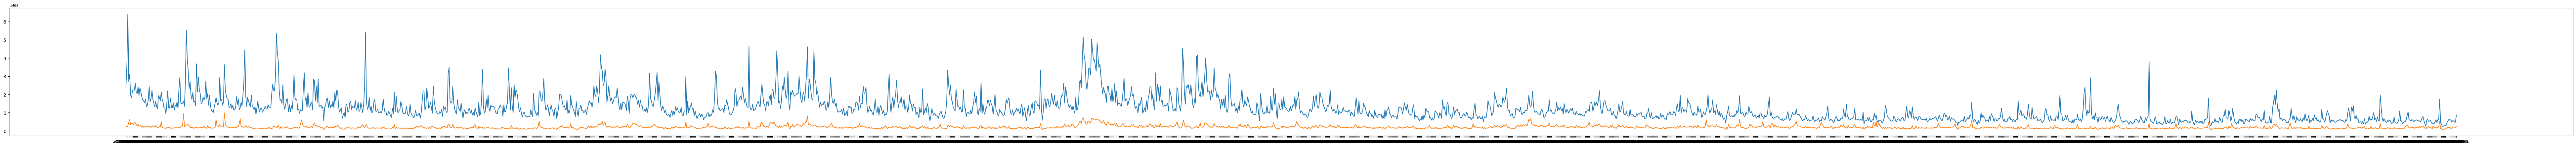

In [4]:
# Visualising 4years day record
N = 2511
_df = DF[1][:N]
_df2 = DF[2][:N]
plt.figure(figsize=(100, 5))
plt.plot(_df['Date'], _df['Volume'], label='Asset 001')
plt.plot(_df2['Date'], _df2['Volume'], label='Asset 002')
plt.legend
plt.show()

In [6]:
from matplotlib.colors import ListedColormap

# Wide panel: one Close series per asset, aligned on Date
closes = {}
for i, df in DF.items():
    s = df.copy()
    s["Date"] = pd.to_datetime(s["Date"])
    closes[i] = s.set_index("Date")["Close"]

panel = pd.DataFrame(closes).sort_index()   # dates × assets
available = panel.notna().T                 # assets × dates  (True = data exists)

# # --- first plot: availability map ---
# fig, ax = plt.subplots(figsize=(14, 8))
# ax.imshow(
#     available.astype(float),
#     aspect="auto",
#     interpolation="nearest",
#     cmap=ListedColormap(["white", "#1f4e79"]),
#     vmin=0,
#     vmax=1,
#     origin="upper",
# )

# yticks = list(range(0, available.shape[0], 10))
# ax.set_yticks(yticks)
# ax.set_yticklabels([f"Asset_{available.index[i]:03d}" for i in yticks])

dates = available.columns
year_idx = [i for i, d in enumerate(dates) if i == 0 or d.year != dates[i - 1].year]
# ax.set_xticks(year_idx)
# ax.set_xticklabels([dates[i].strftime("%Y") for i in year_idx])

# ax.set_xlabel("Date")
# ax.set_ylabel("Asset")
# ax.set_title("Data availability (shaded = present, white = missing)")
# plt.tight_layout()
# plt.show()

# Instant read on late starts / early stops / internal holes
first = available.idxmax(axis=1)
last = available.iloc[:, ::-1].idxmax(axis=1)
n_obs = available.sum(axis=1)
span = available.columns.get_indexer(last) - available.columns.get_indexer(first) + 1
internal_holes = (n_obs < span).sum()

print(f"calendar: {dates.min().date()} → {dates.max().date()}  ({len(dates)} dates)")
print(f"late start : {(first > dates.min()).sum()}")
print(f"early stop : {(last < dates.max()).sum()}")
print(f"internal holes: {internal_holes}")

calendar: 2016-01-25 → 2026-01-16  (2511 dates)
late start : 0
early stop : 0
internal holes: 0


In [ ]:
trdf_ ={}
tedf_ = {}

for i, df in DF.items():
    trdf_[i] = df.copy()

